In [ ]:

# Install datasets Library (if not already installed)
# !pip install datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [ ]:
job_counts = df.job_title_short.value_counts()

job_counts

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


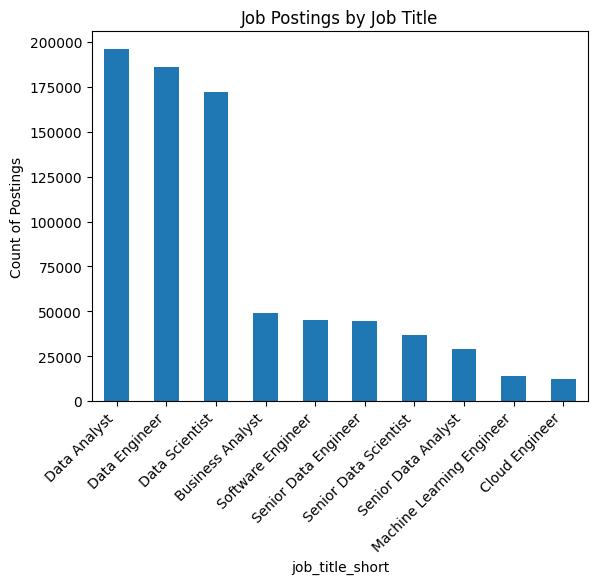

In [ ]:

job_counts.plot(kind='bar')
plt.ylabel('Count of Postings')
plt.title('Job Postings by Job Title')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='job_title_short'>

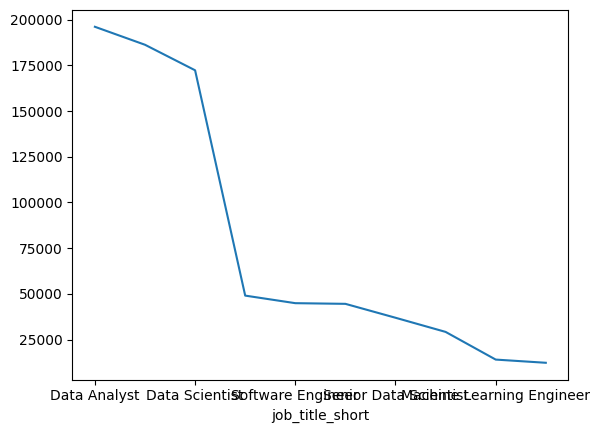

In [ ]:
job_counts.plot(kind='line')

<Axes: xlabel='job_posted_date'>

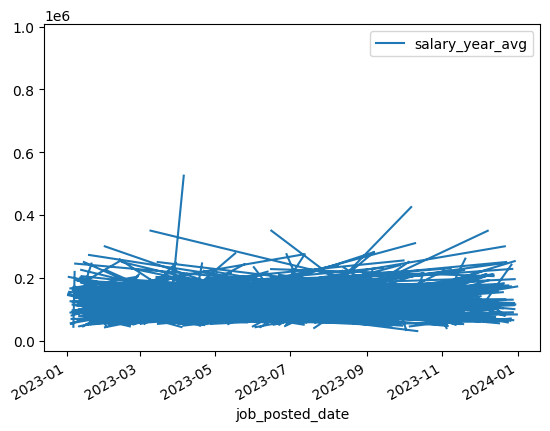

In [ ]:
df.plot(x='job_posted_date', y='salary_year_avg', kind='line')

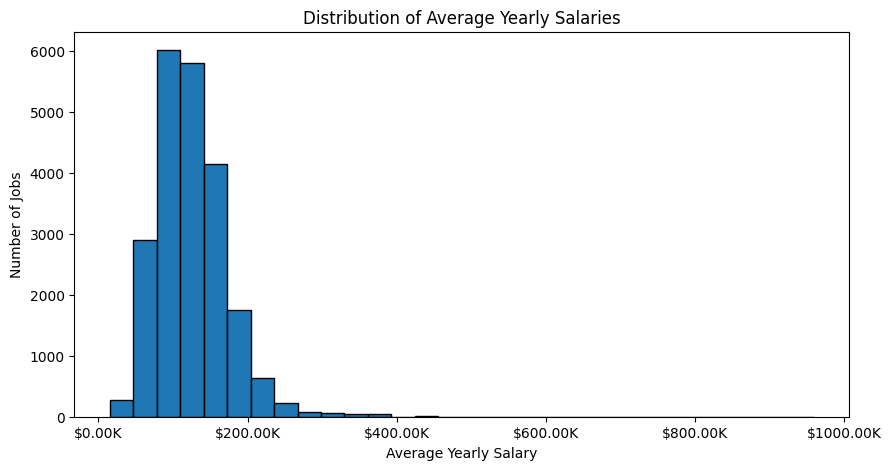

In [ ]:
from matplotlib.ticker import FuncFormatter

# Drop rows with NA values in 'salary_year_avg'
df_nan = df.dropna(subset=['salary_year_avg'])

# Define the formatter function
def to_k(x, pos):
    """Convert number to string with 'K' as thousands."""
    return f'${int(x/1000):.2f}K'

# Create formatter using FuncFormatter
formatter = FuncFormatter(to_k)

# Create histogram
plt.figure(figsize=(10, 5))
plt.hist(df_nan['salary_year_avg'], bins=30, edgecolor='black')

# Set title and labels
plt.title('Distribution of Average Yearly Salaries')
plt.xlabel('Average Yearly Salary')
plt.ylabel('Number of Jobs')

# Apply the formatter to the x-axis
plt.gca().xaxis.set_major_formatter(formatter)

# Show the plot
plt.show()

In [ ]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

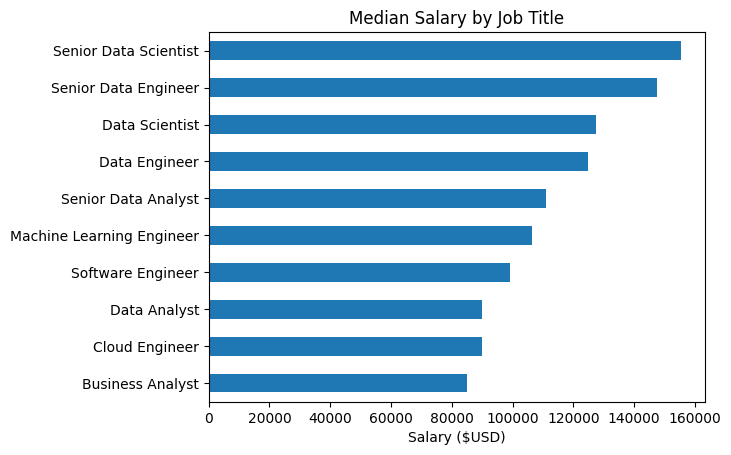

In [ ]:
job_salary.plot(kind='barh')
plt.xlabel('Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()